# Example steps and codes running hypoddpy for earthquake relocation

In [1]:
#import needed packages.
""" 
    Download hypoDD at https://www.ldeo.columbia.edu/~felixw/hypoDD.html
    Or use the copy included in this python interface package.
"""
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from hypoxpy.utils import tic, toc
import hypoxpy.HypoDDCore as hypoddcore
import matplotlib.pyplot as plt

In [2]:
binpath='/Users/xtyang/bin' #path to hypoDD binaries.
indir='input'
outdir='output'

namebase='EQ_HYP'
station_file=os.path.join(indir,'EQ_HYP_station_original.csv')
station_file_reformat=os.path.join(indir,'station.dat')
phase_file=os.path.join(indir,'EQ_HYP_phase_original.dat') #input original phase file.
phase_file_reformat=f'{indir}/{namebase}_phase_ready.pha' #output reformatted phase file for hypoDD.
phase_file_updated=f'{outdir}/{namebase}_phase_relocated.pha' #output updated phase file after relocation.
dep_corr = 5

#
cleanup=True #whether to clean up intermediate files.

#subset params
time_range='20190704-20190710'
lat_range = [35.45,36.05]
lon_range = [-117.8,-117.25]


In [3]:
print("[TIMER] HypoDD started")

# -------------------------------
# 2. Configure hypoDD running settings
# -------------------------------
hypoddconfig = hypoddcore.HypoDDConfig(binpath=binpath,indir=indir,outdir=outdir,namebase=namebase,
    station_file=station_file,phase_file=phase_file_reformat)

# 3. reformat station and phase files
hypoddcore.reformat_stationfile(station_file, station_file_reformat)

hypoddcore.reformat_phasefile(hypoddconfig, phase_file, phase_file_out=phase_file_reformat, \
                              time_range=time_range, lat_range=lat_range, lon_range=lon_range)

# -------------------------------
# 4. hypoDD (core relocation)
# -------------------------------
t0 = tic()
print(f"Running hypoDD ")
out_catalog = hypoddconfig.run(cleanup=cleanup)
toc(t0, f"Run hypoDD")

# 5. update original phase file with hypoDD relocation results
hypoddcore.update_phasefile_with_reloc(phase_file, out_catalog, phase_file_updated)




[TIMER] HypoDD started
[INFO] Wrote single phase file: input/EQ_HYP_phase_ready.pha
[INFO] Number of events: 1318
Running hypoDD 
running ph2dt...
[INFO] ph2dt completed: output/EQ_HYP.ph2dt
[INFO] Wrote output catalog: output/EQ_HYP.ctlg with 1281 events.
[INFO] Cleaned up intermediate files.
[TIMER] Run hypoDD: 3.83 s


In [4]:
quakes=pd.read_csv(out_catalog,header=None,names=["datetime","latitude","longitude","depth","magnitude","evid"])
print(quakes)

                         datetime   latitude   longitude  depth  magnitude  \
0     2019-07-04T20:06:08.120000Z  35.703650 -117.471069  12.81        3.4   
1     2019-07-04T17:40:18.480000Z  35.713546 -117.500952  12.32        4.2   
2     2019-07-04T18:18:45.640000Z  35.634037 -117.600749  12.65        3.2   
3     2019-07-04T18:27:59.480000Z  35.751383 -117.538444   7.17        4.4   
4     2019-07-04T20:37:29.600000Z  35.645589 -117.534611   7.50        1.9   
...                           ...        ...         ...    ...        ...   
1276  2019-07-05T16:29:34.290000Z  35.713017 -117.478003   8.60        1.2   
1277  2019-07-05T16:34:32.650000Z  35.745459 -117.544116   4.77        1.1   
1278  2019-07-05T16:52:22.500000Z  35.726526 -117.535645   1.53        0.8   
1279  2019-07-05T16:56:49.470000Z  35.694820 -117.464030   1.45        1.6   
1280  2019-07-05T17:08:59.760000Z  35.691366 -117.601294   9.22        1.1   

      evid  
0        0  
1        1  
2        2  
3        3 

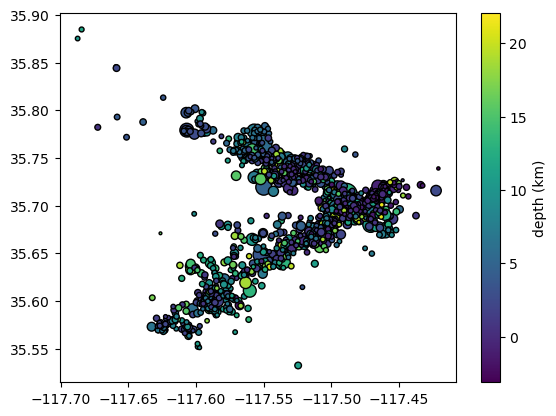

In [5]:
plt.scatter(quakes.longitude,quakes.latitude,5*np.power(2,quakes.magnitude),quakes.depth,edgecolors='k')
plt.colorbar(label='depth (km)')
plt.show()